In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual global
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

# Cargar el dataset limpio
df = pd.read_csv('../data/processed/train_clean.csv', parse_dates=['Date'])

print(f"✓ Dataset cargado correctamente")
print(f"  Filas: {df.shape[0]:,}")
print(f"  Columnas: {df.shape[1]}")
print(f"  Período: {df['Date'].min().date()} → {df['Date'].max().date()}")

✓ Dataset cargado correctamente
  Filas: 844,392
  Columnas: 18
  Período: 2013-01-01 → 2015-07-31


C:\Users\diego\AppData\Local\Temp\ipykernel_63360\4153127658.py:13: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/processed/train_clean.csv', parse_dates=['Date'])


In [2]:
# Corregir el warning de StateHoliday
df = pd.read_csv('../data/processed/train_clean.csv', 
                 parse_dates=['Date'],
                 dtype={'StateHoliday': str},
                 low_memory=False)

print("✓ Dataset recargado sin warnings")
print(f"  Período cubierto: 2.5 años de ventas diarias")
print(f"  Tiendas únicas: {df['Store'].nunique()}")
print(f"  Promedio de ventas diarias: ${df['Sales'].mean():,.0f}")

✓ Dataset recargado sin warnings
  Período cubierto: 2.5 años de ventas diarias
  Tiendas únicas: 1115
  Promedio de ventas diarias: $6,956


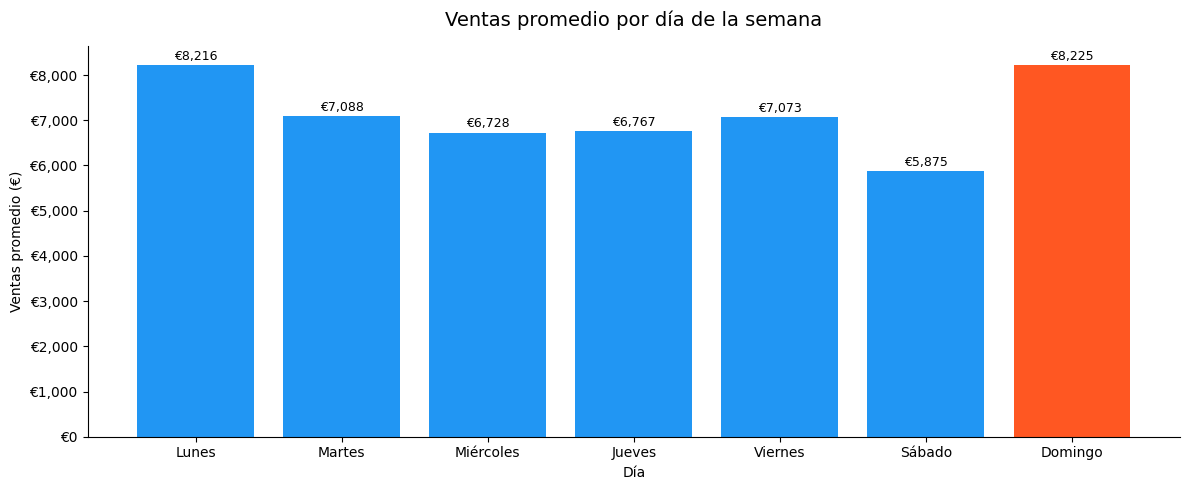

✓ Gráfico guardado en outputs/


In [3]:
# ================================================
# PREGUNTA 1: ¿Qué días de la semana venden más?
# ================================================

dias = {1: 'Lunes', 2: 'Martes', 3: 'Miércoles', 
        4: 'Jueves', 5: 'Viernes', 6: 'Sábado', 7: 'Domingo'}

ventas_por_dia = df.groupby('DayOfWeek')['Sales'].mean().reset_index()
ventas_por_dia['DayName'] = ventas_por_dia['DayOfWeek'].map(dias)

fig, ax = plt.subplots()
bars = ax.bar(ventas_por_dia['DayName'], 
              ventas_por_dia['Sales'],
              color=['#2196F3' if x != ventas_por_dia['Sales'].idxmax() 
                     else '#FF5722' for x in range(len(ventas_por_dia))])

ax.set_title('Ventas promedio por día de la semana', fontsize=14, pad=15)
ax.set_xlabel('Día')
ax.set_ylabel('Ventas promedio (€)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

# Agregar valores encima de cada barra
for bar, valor in zip(bars, ventas_por_dia['Sales']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'€{valor:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/01_ventas_por_dia.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado en outputs/")

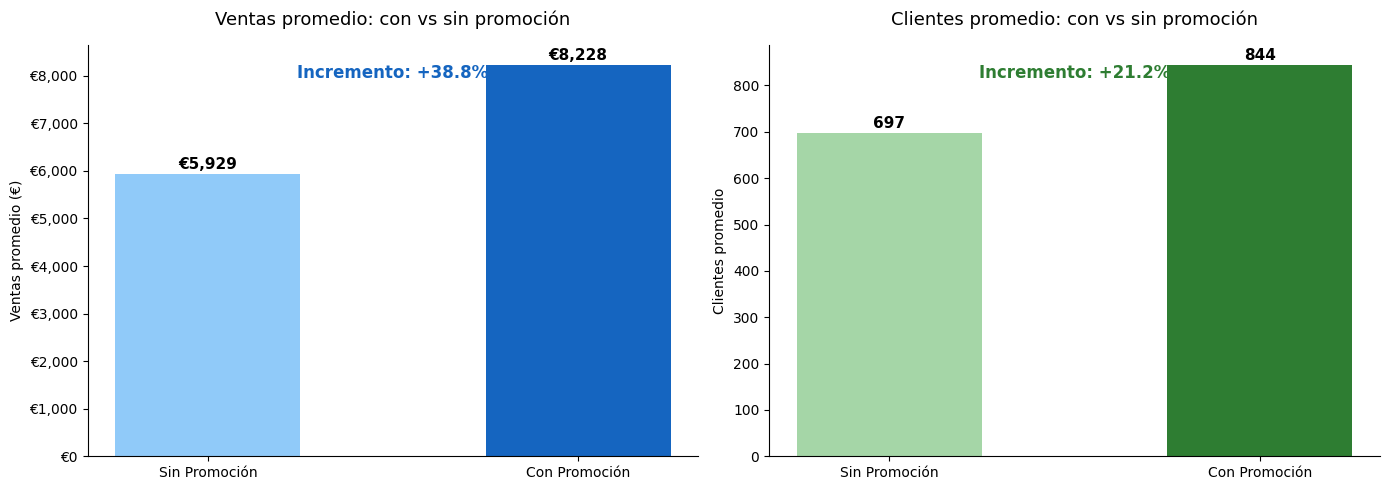


 INSIGHT:
  Las promociones aumentan las ventas un 38.8%
  Y atraen un 21.2% más de clientes


In [4]:
# ================================================
# PREGUNTA 2: ¿Las promociones aumentan las ventas?
# ================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1 — Ventas promedio con y sin promo
ventas_promo = df.groupby('Promo')['Sales'].mean()
labels = ['Sin Promoción', 'Con Promoción']
colors = ['#90CAF9', '#1565C0']

bars = axes[0].bar(labels, ventas_promo.values, color=colors, width=0.5)
axes[0].set_title('Ventas promedio: con vs sin promoción', fontsize=13, pad=15)
axes[0].set_ylabel('Ventas promedio (€)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

for bar, valor in zip(bars, ventas_promo.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'€{valor:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Calcular incremento porcentual
incremento = ((ventas_promo[1] - ventas_promo[0]) / ventas_promo[0]) * 100
axes[0].text(0.5, 0.92, f'Incremento: +{incremento:.1f}%', 
             transform=axes[0].transAxes, ha='center',
             fontsize=12, color='#1565C0', fontweight='bold')

# Gráfico 2 — Clientes promedio con y sin promo
clientes_promo = df.groupby('Promo')['Customers'].mean()

bars2 = axes[1].bar(labels, clientes_promo.values, color=['#A5D6A7', '#2E7D32'], width=0.5)
axes[1].set_title('Clientes promedio: con vs sin promoción', fontsize=13, pad=15)
axes[1].set_ylabel('Clientes promedio')

for bar, valor in zip(bars2, clientes_promo.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{valor:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

incremento_clientes = ((clientes_promo[1] - clientes_promo[0]) / clientes_promo[0]) * 100
axes[1].text(0.5, 0.92, f'Incremento: +{incremento_clientes:.1f}%',
             transform=axes[1].transAxes, ha='center',
             fontsize=12, color='#2E7D32', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/02_impacto_promociones.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n INSIGHT:")
print(f"  Las promociones aumentan las ventas un {incremento:.1f}%")
print(f"  Y atraen un {incremento_clientes:.1f}% más de clientes")

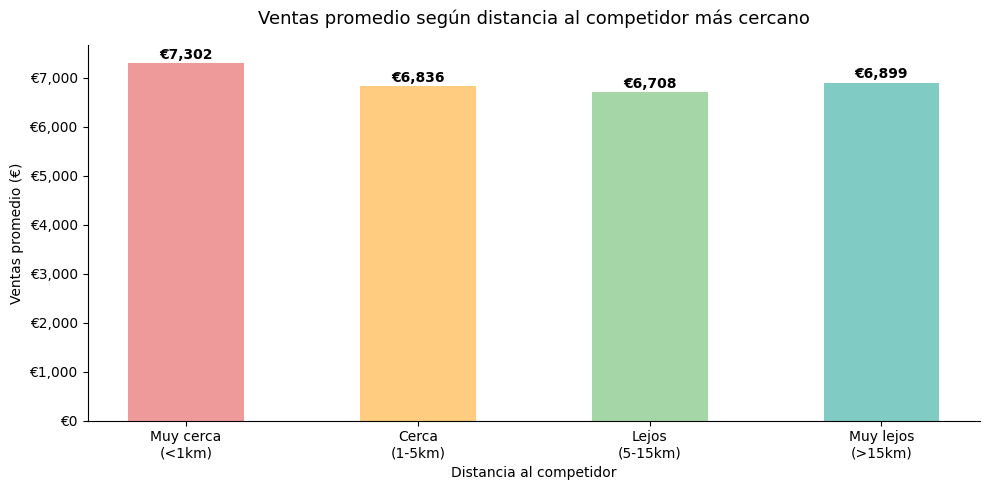


 INSIGHT:
  Tiendas con competidor muy lejos venden -5.5% más
  que tiendas con competidor muy cerca


In [5]:
# ================================================
# PREGUNTA 3: ¿Competidores cerca afectan las ventas?
# ================================================

# Crear categorías de distancia al competidor
bins = [0, 1000, 5000, 15000, df['CompetitionDistance'].max()]
labels_dist = ['Muy cerca\n(<1km)', 'Cerca\n(1-5km)', 
               'Lejos\n(5-15km)', 'Muy lejos\n(>15km)']

df['DistanciaCategoria'] = pd.cut(df['CompetitionDistance'], 
                                   bins=bins, labels=labels_dist)

ventas_distancia = df.groupby('DistanciaCategoria', observed=True)['Sales'].mean()

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#EF9A9A', '#FFCC80', '#A5D6A7', '#80CBC4']
bars = ax.bar(ventas_distancia.index, ventas_distancia.values, color=colors, width=0.5)

ax.set_title('Ventas promedio según distancia al competidor más cercano', 
             fontsize=13, pad=15)
ax.set_xlabel('Distancia al competidor')
ax.set_ylabel('Ventas promedio (€)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

for bar, valor in zip(bars, ventas_distancia.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'€{valor:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/03_competencia_ventas.png', dpi=150, bbox_inches='tight')
plt.show()

# Calcular diferencia entre extremos
diff = ((ventas_distancia.iloc[-1] - ventas_distancia.iloc[0]) / ventas_distancia.iloc[0]) * 100
print(f"\n INSIGHT:")
print(f"  Tiendas con competidor muy lejos venden {diff:.1f}% más")
print(f"  que tiendas con competidor muy cerca")

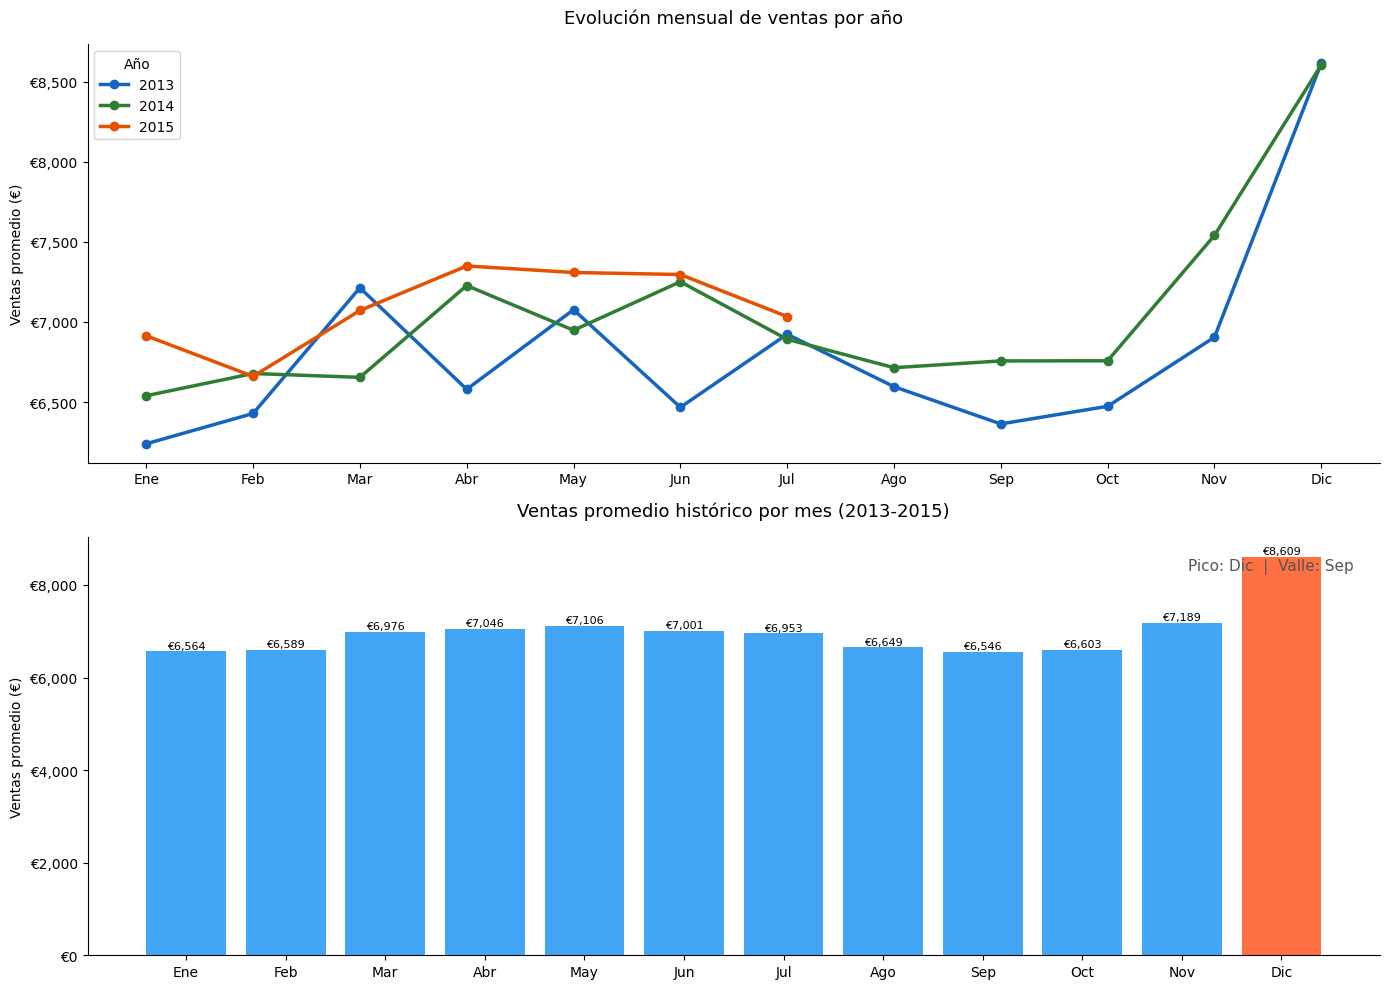


 INSIGHT:
  Mes de mayor venta: Dic
  Mes de menor venta: Sep
  Diferencia: €2,063


In [6]:
# ================================================
# PREGUNTA 4: ¿Hay estacionalidad en las ventas?
# ================================================

df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

meses = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun',
         7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}

ventas_mes = df.groupby(['Year', 'Month'])['Sales'].mean().reset_index()
ventas_mes['MonthName'] = ventas_mes['Month'].map(meses)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Gráfico 1 — Línea de ventas por mes y año
colors_year = {2013: '#1565C0', 2014: '#2E7D32', 2015: '#E65100'}
for year in ventas_mes['Year'].unique():
    data_year = ventas_mes[ventas_mes['Year'] == year]
    axes[0].plot(data_year['Month'], data_year['Sales'], 
                marker='o', linewidth=2.5, markersize=6,
                label=str(year), color=colors_year[year])

axes[0].set_title('Evolución mensual de ventas por año', fontsize=13, pad=15)
axes[0].set_ylabel('Ventas promedio (€)')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(meses.values())
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
axes[0].legend(title='Año')

# Gráfico 2 — Promedio histórico por mes (los 3 años combinados)
ventas_mes_avg = df.groupby('Month')['Sales'].mean()
colors_bars = ['#FF7043' if v == ventas_mes_avg.max() 
               else '#42A5F5' for v in ventas_mes_avg.values]

bars = axes[1].bar(list(meses.values()), ventas_mes_avg.values, color=colors_bars)
axes[1].set_title('Ventas promedio histórico por mes (2013-2015)', fontsize=13, pad=15)
axes[1].set_ylabel('Ventas promedio (€)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

for bar, valor in zip(bars, ventas_mes_avg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f'€{valor:,.0f}', ha='center', va='bottom', fontsize=8)

mes_pico = meses[ventas_mes_avg.idxmax()]
mes_bajo = meses[ventas_mes_avg.idxmin()]
axes[1].text(0.98, 0.92, f'Pico: {mes_pico}  |  Valle: {mes_bajo}',
            transform=axes[1].transAxes, ha='right',
            fontsize=11, color='#555')

plt.tight_layout()
plt.savefig('../outputs/04_estacionalidad.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n INSIGHT:")
print(f"  Mes de mayor venta: {mes_pico}")
print(f"  Mes de menor venta: {mes_bajo}")
print(f"  Diferencia: €{ventas_mes_avg.max() - ventas_mes_avg.min():,.0f}")


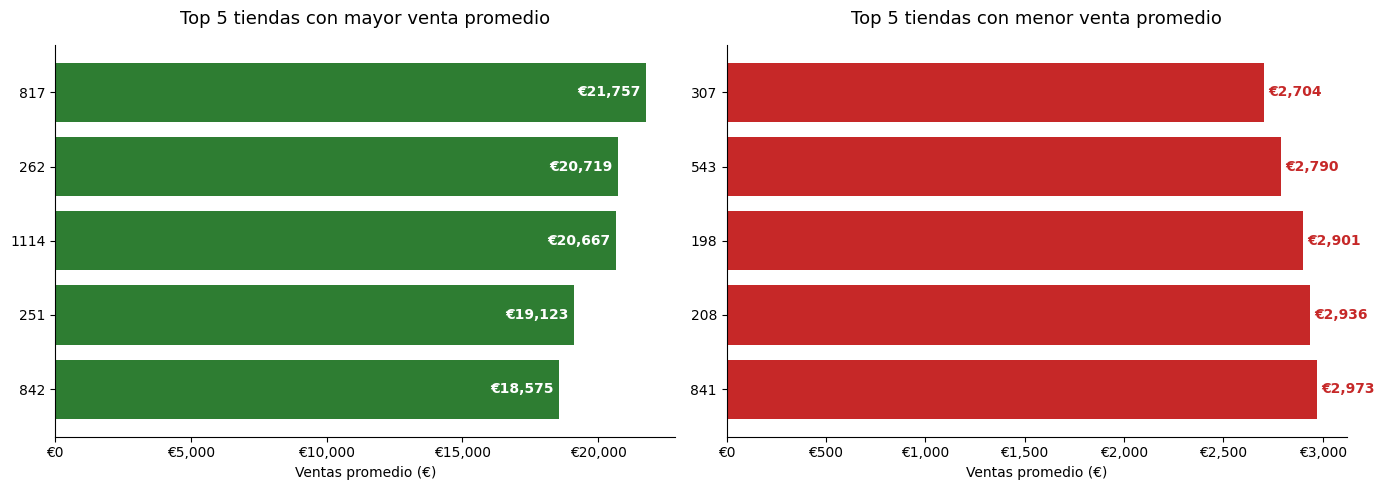

In [7]:
# ================================================
# TOP 5 — Tiendas que más y menos venden
# ================================================

ventas_por_tienda = df.groupby('Store').agg(
    Ventas_Promedio=('Sales', 'mean'),
    Ventas_Totales=('Sales', 'sum'),
    Total_Clientes=('Customers', 'mean'),
    Dias_Operados=('Sales', 'count')
).reset_index().round(2)

# TOP 5 que más venden
top5_mas = ventas_por_tienda.nlargest(5, 'Ventas_Promedio')

# TOP 5 que menos venden
top5_menos = ventas_por_tienda.nsmallest(5, 'Ventas_Promedio')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico TOP 5 más
bars1 = axes[0].barh(
    top5_mas['Store'].astype(str),
    top5_mas['Ventas_Promedio'],
    color='#2E7D32'
)
axes[0].set_title('Top 5 tiendas con mayor venta promedio', fontsize=13, pad=15)
axes[0].set_xlabel('Ventas promedio (€)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
axes[0].invert_yaxis()

for bar, valor in zip(bars1, top5_mas['Ventas_Promedio']):
    axes[0].text(bar.get_width() - 200, bar.get_y() + bar.get_height()/2,
                f'€{valor:,.0f}', ha='right', va='center', 
                fontsize=10, fontweight='bold', color='white')

# Gráfico TOP 5 menos
bars2 = axes[1].barh(
    top5_menos['Store'].astype(str),
    top5_menos['Ventas_Promedio'],
    color='#C62828'
)
axes[1].set_title('Top 5 tiendas con menor venta promedio', fontsize=13, pad=15)
axes[1].set_xlabel('Ventas promedio (€)')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
axes[1].invert_yaxis()

for bar, valor in zip(bars2, top5_menos['Ventas_Promedio']):
    axes[1].text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                f'€{valor:,.0f}', ha='left', va='center',
                fontsize=10, fontweight='bold', color='#C62828')

plt.tight_layout()
plt.savefig('../outputs/05_top_tiendas.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Detalle en tabla
print("=" * 55)
print("TOP 5 TIENDAS — MAYOR VENTA PROMEDIO")
print("=" * 55)
print(f"{'Tienda':>8} {'Venta Prom':>12} {'Venta Total':>15} {'Clientes':>10}")
print("-" * 55)
for _, row in top5_mas.iterrows():
    print(f"{int(row['Store']):>8} "
          f"€{row['Ventas_Promedio']:>10,.0f} "
          f"€{row['Ventas_Totales']:>13,.0f} "
          f"{row['Total_Clientes']:>9,.0f}")

print("\n" + "=" * 55)
print("TOP 5 TIENDAS — MENOR VENTA PROMEDIO")
print("=" * 55)
print(f"{'Tienda':>8} {'Venta Prom':>12} {'Venta Total':>15} {'Clientes':>10}")
print("-" * 55)
for _, row in top5_menos.iterrows():
    print(f"{int(row['Store']):>8} "
          f"€{row['Ventas_Promedio']:>10,.0f} "
          f"€{row['Ventas_Totales']:>13,.0f} "
          f"{row['Total_Clientes']:>9,.0f}")

TOP 5 TIENDAS — MAYOR VENTA PROMEDIO
  Tienda   Venta Prom     Venta Total   Clientes
-------------------------------------------------------
     817 €    21,757 €   17,057,867     3,131
     262 €    20,719 €   19,516,842     3,402
    1114 €    20,667 €   16,202,585     3,201
     251 €    19,123 €   14,896,870     2,450
     842 €    18,575 €   11,553,523     1,149

TOP 5 TIENDAS — MENOR VENTA PROMEDIO
  Tienda   Venta Prom     Venta Total   Clientes
-------------------------------------------------------
     307 €     2,704 €    2,114,322       308
     543 €     2,790 €    2,179,287       240
     198 €     2,901 €    2,268,273       338
     208 €     2,936 €    2,302,052       413
     841 €     2,973 €    2,318,635       412


# 📊 Resumen Ejecutivo — Rossmann Store Sales EDA

**Dataset analizado:** 844,392 registros · 1,115 tiendas · Período 2013–2015

---

## Hallazgos clave

### 1. Días de la semana
Los **domingos y lunes** concentran los picos de demanda superando €8,000 en ventas promedio. Las tiendas abiertas en domingo capturan demanda concentrada precisamente porque pocas competidoras operan ese día — una ventana de oportunidad que la mayoría de la cadena no está aprovechando.

### 2. Las promociones valen más de lo que cuestan
Las promociones no solo atraen más gente — cambian el comportamiento de compra. Las ventas suben **+38.8%** pero los clientes solo **+21.2%**, lo que significa que cada persona que entra durante una promo gasta significativamente más. El problema no es si hacer promociones, sino **cuándo y dónde concentrarlas**.

### 3. La competencia cerca no es una amenaza — es una señal
Las tiendas con competidor a **menos de 1km generan €403 más** por día que las tiendas aisladas. Estas ubicaciones no sufren la competencia — se benefician del tráfico que ella genera. Abrir o fortalecer tiendas en zonas de alta densidad comercial es una decisión respaldada por los datos.

### 4. Diciembre no es un buen mes — es el mes
La cadena genera en diciembre un **+31% más** que en septiembre, su peor mes. Eso significa que una porción crítica del ingreso anual se juega en 31 días. Llegar a diciembre sin stock, sin personal y sin promociones activas no es un error operativo — es un error estratégico.

### 5. Hay dos cadenas dentro de una
La tienda **#817 vende €21,757 en promedio diario**. La tienda **#307 vende €2,704**. Esa brecha de **8 veces** entre la mejor y la peor no es ruido estadístico — es evidencia de que dentro de Rossmann conviven modelos de negocio radicalmente distintos. Las decisiones que funcionan para una no necesariamente funcionan para la otra.

---

## Métricas clave

| Métrica | Valor |
|---|---|
| Venta promedio diaria (cadena) | €6,956 |
| Tienda de mayor rendimiento | #817 · €21,757/día |
| Tienda de menor rendimiento | #307 · €2,704/día |
| Brecha entre mejor y peor tienda | 8x |
| Incremento en ventas con promoción | +38.8% |
| Mes pico vs mes valle | Dic €8,609 vs Sep €6,546 (+31%) |
| Ventaja en zonas de alta competencia | +€403/día vs tiendas aisladas |

---

## Recomendacines


Los datos cuentan una historia clara: **esta cadena no tiene un problema de ventas — tiene un problema de concentración.**

El 40% del potencial de ingresos se juega en un solo mes (diciembre), en un subconjunto de tiendas de alto rendimiento, y en los días en que hay promoción activa. Fuera de esas condiciones, los números caen de forma predecible.

Tres acciones concretas respaldadas por este análisis:

**1. Activar promociones en octubre y noviembre, no en diciembre.**
Diciembre ya vende solo. El momento de invertir en promoción es antes del pico, cuando el cliente todavía está decidiendo dónde comprar. Llegar primero vale más que llegar con más presupuesto.

**2. Estudiar la tienda #817 como modelo operativo.**
Una tienda que vende 8 veces más que la peor de la cadena no tiene suerte — tiene un sistema. Identificar qué hace diferente en términos de ubicación, tipo de surtido, frecuencia de promociones y atención al cliente, y replicarlo donde sea posible.

**3. Tomar una decisión sobre las tiendas de bajo rendimiento.**
La tienda #307 y sus pares no son un problema de gestión que se resuelve con más esfuerzo. Con €2,704 de venta diaria promedio, la pregunta no es cómo mejorarlas — es si el capital invertido en ellas genera más valor ahí o reubicado en zonas de mayor tráfico.

---

*Análisis realizado con Python · pandas · matplotlib · seaborn*